In [112]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import date_format
from pyspark.sql.functions import avg
from pyspark.sql.functions import median
from pyspark.sql.functions import split, col
from pyspark.sql.functions import hour, minute, second
from pyspark.sql.functions import to_date, dayofmonth, month, year, dayofweek
from pyspark.sql.window import Window
from pyspark.sql.functions import *




from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.functions import col, when
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [113]:
spark = SparkSession.builder \
        .appName("Training") \
        .master("local[*]") \
        .config("spark.driver.memory", "8g") \
        .config("spark.sql.shuffle.partitions", "4") \
        .getOrCreate()

In [114]:
data_path = "D:/HK6/ĐỒ ÁN HPC & BIG DATA/data/preprocessed_data.csv"    
df = spark.read.csv(data_path, header=True, inferSchema=True)

In [115]:
df.printSchema() 

root
 |-- Time: timestamp (nullable = true)
 |-- Date: date (nullable = true)
 |-- Sender_account: long (nullable = true)
 |-- Receiver_account: long (nullable = true)
 |-- Amount: double (nullable = true)
 |-- Payment_currency: string (nullable = true)
 |-- Received_currency: string (nullable = true)
 |-- Sender_bank_location: string (nullable = true)
 |-- Receiver_bank_location: string (nullable = true)
 |-- Payment_type: string (nullable = true)
 |-- Is_laundering: integer (nullable = true)
 |-- Laundering_type: string (nullable = true)



In [116]:
print(df.count())

8000000


In [117]:
df.show(5)           # xem 5 dòng đầu


+-------------------+----------+--------------+----------------+--------+----------------+-----------------+--------------------+----------------------+------------+-------------+--------------------+
|               Time|      Date|Sender_account|Receiver_account|  Amount|Payment_currency|Received_currency|Sender_bank_location|Receiver_bank_location|Payment_type|Is_laundering|     Laundering_type|
+-------------------+----------+--------------+----------------+--------+----------------+-----------------+--------------------+----------------------+------------+-------------+--------------------+
|2026-05-14 10:35:19|2022-10-07|    8724731955|      2769355426| 1459.15|       UK pounds|        UK pounds|                  UK|                    UK|Cash Deposit|            0|Normal_Cash_Deposits|
|2026-05-14 10:35:20|2022-10-07|    1491989064|      8401255335| 6019.64|       UK pounds|           Dirham|                  UK|                   UAE|Cross-border|            0|      Normal_Fan_

In [118]:
df.groupBy("Is_laundering").count().show()

+-------------+-------+
|Is_laundering|  count|
+-------------+-------+
|            0|7991894|
|            1|   8106|
+-------------+-------+



## Feature Engineering

In [119]:
df.columns

['Time',
 'Date',
 'Sender_account',
 'Receiver_account',
 'Amount',
 'Payment_currency',
 'Received_currency',
 'Sender_bank_location',
 'Receiver_bank_location',
 'Payment_type',
 'Is_laundering',
 'Laundering_type']

In [120]:
# =====================================================
# 1. Convert Time sang timestamp
# =====================================================

df = df.withColumn(
    "ts",
    col("Time").cast("timestamp")
)

# =====================================================
# 2. Feature: số transaction trong 1 giờ gần nhất
# =====================================================

window_1h = Window.partitionBy("Sender_account") \
    .orderBy(col("ts").cast("long")) \
    .rangeBetween(-3600, 0)

df = df.withColumn(
    "txn_count_1h",
    count("*").over(window_1h)
)

# =====================================================
# 3. Feature: tổng amount trong 24 giờ gần nhất
# =====================================================

window_24h = Window.partitionBy("Sender_account") \
    .orderBy(col("ts").cast("long")) \
    .rangeBetween(-86400, 0)

df = df.withColumn(
    "amount_sum_24h",
    sum("Amount").over(window_24h)
)

# =====================================================
# 4. Feature: average amount trong 7 ngày gần nhất
# =====================================================

window_7d = Window.partitionBy("Sender_account") \
    .orderBy(col("ts").cast("long")) \
    .rangeBetween(-604800, 0)

df = df.withColumn(
    "amount_avg_7d",
    avg("Amount").over(window_7d)
)

# =====================================================
# 5. Feature: số giây từ transaction trước đó
# =====================================================

window_lag = Window.partitionBy("Sender_account") \
    .orderBy("ts")

df = df.withColumn(
    "prev_ts",
    lag("ts").over(window_lag)
)

df = df.withColumn(
    "seconds_since_prev",
    unix_timestamp("ts") - unix_timestamp("prev_ts")
)

# =====================================================
# 6. Fill null cho transaction đầu tiên
# =====================================================

df = df.fillna({
    "seconds_since_prev": 999999
})

# =====================================================
# 7. Kiểm tra kết quả
# =====================================================

df.select(
    "Sender_account",
    "Time",
    "Amount",
    "txn_count_1h",
    "amount_sum_24h",
    "amount_avg_7d",
    "seconds_since_prev"
).show(10, truncate=False)

+--------------+-------------------+--------+------------+--------------+-----------------+------------------+
|Sender_account|Time               |Amount  |txn_count_1h|amount_sum_24h|amount_avg_7d    |seconds_since_prev|
+--------------+-------------------+--------+------------+--------------+-----------------+------------------+
|28511         |2026-05-14 19:19:18|6197.07 |1           |6197.07       |6197.07          |999999            |
|28511         |2026-05-14 19:38:10|7147.58 |2           |13344.65      |6672.325         |1132              |
|28511         |2026-05-14 20:51:59|4109.92 |1           |17454.57      |5818.19          |4429              |
|28511         |2026-05-14 23:02:45|6755.32 |1           |24209.89      |6052.4725        |7846              |
|28511         |2026-05-14 23:28:15|6371.25 |2           |30581.14      |6116.228         |1530              |
|28511         |2026-05-14 23:31:38|3878.0  |3           |34459.14      |5743.19          |203               |
|

In [121]:
df = df.withColumnRenamed('Time', 'DateTime')

In [122]:
df = df.withColumn("Hour", hour("DateTime")) \
       .withColumn("Minute", minute("DateTime")) \
       .withColumn("Second", second("DateTime"))

In [123]:
df = df.withColumn("Date_parsed", to_date(col("Date"), "yyyy-MM-dd")) \
       .withColumn("Day",         dayofmonth(col("Date_parsed"))) \
       .withColumn("Month",       month(col("Date_parsed"))) \
       .withColumn("DayOfWeek",   dayofweek(col("Date_parsed"))) \
       .drop("Date", "Date_parsed")

In [124]:
df = df.drop('Laundering_type')

In [125]:
df = df.drop('DateTime')

In [126]:
df = df.drop('prev_ts')

In [127]:
df = df.drop('ts')

In [128]:
# # 1. Xử lý class weight
# total   = df.count()
# n_fraud = df.filter(col("Is_laundering") == 1).count()
# n_normal = total - n_fraud
# ratio   = n_normal / n_fraud

# print(f"Tổng: {total:,}")
# print(f"Fraud: {n_fraud:,} ({n_fraud/total*100:.2f}%)")
# print(f"Normal: {n_normal:,} ({n_normal/total*100:.2f}%)")
# print(f"Ratio: {ratio:.1f}x")

# df = df.withColumn("classWeight",
#     when(col("Is_laundering") == 1, ratio).otherwise(1.0)
# )



### Oversampling

In [129]:
# Train/test split
train_df_, test_df = df.limit(300000).randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_df_.count():,} | Test: {test_df.count():,}")

Train: 239,843 | Test: 60,157


In [130]:


# =====================================================
# 2. Tách fraud và normal trong TRAIN
# =====================================================

fraud_train = train_df_.filter(
    col("Is_laundering") == 1
)

normal_train = train_df_.filter(
    col("Is_laundering") == 0
)

# =====================================================
# 3. Count
# =====================================================

fraud_count = fraud_train.count()
normal_count = normal_train.count()

print("Normal:", normal_count)
print("Fraud :", fraud_count)

# =====================================================
# 4. Oversampling
#    Target: fraud chiếm ~30% train set
# =====================================================

target_fraud_ratio = 0.3

desired_fraud_count = (
    target_fraud_ratio * normal_count
) / (1 - target_fraud_ratio)

oversample_ratio = (
    desired_fraud_count / fraud_count
)

print("Oversample ratio:", oversample_ratio)

# =====================================================
# 5. Oversample fraud
# =====================================================

fraud_oversampled = fraud_train.sample(
    withReplacement=True,
    fraction=oversample_ratio,
    seed=42
)

# =====================================================
# 6. Combine lại
# =====================================================

train_df = normal_train.union(
    fraud_oversampled
)


Normal: 239640
Fraud : 203
Oversample ratio: 505.9254046446165


### Class Weight

In [131]:


fraud_weight = 50.0
normal_weight = 1.0

train_df = train_df.withColumn(
    "classWeightCol",
    when(
        col("Is_laundering") == 1,
        fraud_weight
    ).otherwise(normal_weight)
)

## Encode

In [132]:
# Các cột string cần encode
string_cols = [
    "Received_currency",
    "Payment_currency",
    "Sender_bank_location", 
    "Receiver_bank_location",
    "Payment_type"
]

# 2. Tạo StringIndexer cho từng cột
indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=col + "_idx",  
        handleInvalid="keep"    
    )
    for col in string_cols
]

# Các cột số có sẵn (không cần encode)
numeric_cols = [c for c in df.columns 
                if c not in string_cols + ["Is_laundering", "classWeightCol"]]

#  VectorAssembler gộp tất cả lại
encoded_cols = [c + "_idx" for c in string_cols]  # cột vừa encode
input_cols = numeric_cols + encoded_cols



In [133]:
print(input_cols)

['Sender_account', 'Receiver_account', 'Amount', 'txn_count_1h', 'amount_sum_24h', 'amount_avg_7d', 'seconds_since_prev', 'Hour', 'Minute', 'Second', 'Day', 'Month', 'DayOfWeek', 'Received_currency_idx', 'Payment_currency_idx', 'Sender_bank_location_idx', 'Receiver_bank_location_idx', 'Payment_type_idx']


In [134]:
# 2. VectorAssembler 

# class weight feature_cols = [c for c in df.columns if c not in ["Is_laundering", "classWeight"]]

assembler = VectorAssembler(
    inputCols=input_cols,
    outputCol="features",
    handleInvalid="skip"
)

In [135]:
# 3. GBT model
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="Is_laundering",
    maxIter=100,
    maxDepth=6,
    stepSize=0.1,
    seed=42
)

In [136]:
# 4. Pipeline
pipeline = Pipeline(stages=indexers + [assembler, gbt])

## TRAIN

In [137]:
# 3. GBT model
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="Is_laundering",
    weightCol="classWeightCol",
    maxIter=100,
    maxDepth=6,
    stepSize=0.1,
    seed=42
)

In [138]:
# 6. Train
model = pipeline.fit(train_df)


In [139]:
train_df.select(train_df['Is_laundering'] == 1).show(5, truncate=False)

+-------------------+
|(Is_laundering = 1)|
+-------------------+
|false              |
|false              |
|false              |
|false              |
|false              |
+-------------------+
only showing top 5 rows


In [140]:
# 7. Predict
predictions = model.transform(test_df)
predictions.select("Is_laundering", "prediction", "probability").show(10)

+-------------+----------+--------------------+
|Is_laundering|prediction|         probability|
+-------------+----------+--------------------+
|            0|       0.0|[0.81810005102490...|
|            0|       0.0|[0.93404554761494...|
|            0|       0.0|[0.99520454028700...|
|            0|       0.0|[0.98835126136268...|
|            0|       0.0|[0.99565063897842...|
|            0|       0.0|[0.98704233827331...|
|            0|       0.0|[0.98631967357408...|
|            0|       0.0|[0.89313935645820...|
|            0|       0.0|[0.97272935467769...|
|            0|       0.0|[0.98981797829466...|
+-------------+----------+--------------------+
only showing top 10 rows


In [141]:
# # 8. Evaluate
# auc = BinaryClassificationEvaluator(
#     labelCol="Is_laundering",
#     metricName="areaUnderROC"
# ).evaluate(predictions)

# f1 = MulticlassClassificationEvaluator(
#     labelCol="Is_laundering",
#     metricName="f1"
# ).evaluate(predictions)

# precision = MulticlassClassificationEvaluator(
#     labelCol="Is_laundering",
#     metricName="weightedPrecision"
# ).evaluate(predictions)

# recall = MulticlassClassificationEvaluator(
#     labelCol="Is_laundering",
#     metricName="weightedRecall"
# ).evaluate(predictions)

# print(f"\n--- Kết quả ---")
# print(f"AUC:       {auc:.4f}")
# print(f"F1:        {f1:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall:    {recall:.4f}")

--- Kết quả ---
AUC:       0.8116
F1:        0.9990
Precision: 0.9993
Recall:    0.9993

In [142]:


# =========================
# Confusion Matrix
# =========================
print("=== Confusion Matrix ===")

predictions.groupBy("Is_laundering", "prediction") \
    .count() \
    .orderBy("Is_laundering", "prediction") \
    .show()

# =========================
# Accuracy từng class
# =========================
for label in [0.0, 1.0]:

    preds_class = predictions.filter(col("Is_laundering") == label)

    total_class = preds_class.count()

    correct = preds_class.filter(
        col("prediction") == label
    ).count()

    print(f"\n--- Class {int(label)} ({'Fraud' if label == 1 else 'Normal'}) ---")

    print(f"Total:    {total_class:,}")
    print(f"Correct:  {correct:,}")
    print(f"Accuracy: {correct / total_class * 100:.2f}%")

# =========================
# Overall F1
# =========================
f1_score = MulticlassClassificationEvaluator(
    labelCol="Is_laundering",
    predictionCol="prediction",
    metricName="f1"
).evaluate(predictions)

print(f"\nOverall F1 Score: {f1_score:.4f}")

# =========================
# Metrics theo từng class
# =========================
metrics = [
    "fMeasureByLabel",
    "precisionByLabel",
    "recallByLabel"
]

for metric in metrics:

    score_fraud = MulticlassClassificationEvaluator(
        labelCol="Is_laundering",
        predictionCol="prediction",
        metricName=metric,
        metricLabel=1.0
    ).evaluate(predictions)

    score_normal = MulticlassClassificationEvaluator(
        labelCol="Is_laundering",
        predictionCol="prediction",
        metricName=metric,
        metricLabel=0.0
    ).evaluate(predictions)

    print(
        f"{metric}: Fraud={score_fraud:.4f} | Normal={score_normal:.4f}"
    )

=== Confusion Matrix ===
+-------------+----------+-----+
|Is_laundering|prediction|count|
+-------------+----------+-----+
|            0|       0.0|59714|
|            0|       1.0|  397|
|            1|       0.0|   34|
|            1|       1.0|   12|
+-------------+----------+-----+


--- Class 0 (Normal) ---
Total:    60,111
Correct:  59,714
Accuracy: 99.34%

--- Class 1 (Fraud) ---
Total:    46
Correct:  12
Accuracy: 26.09%

Overall F1 Score: 0.9957
fMeasureByLabel: Fraud=0.0527 | Normal=0.9964
precisionByLabel: Fraud=0.0293 | Normal=0.9994
recallByLabel: Fraud=0.2609 | Normal=0.9934


=== Confusion Matrix ===
+-------------+----------+-----+
|Is_laundering|prediction|count|
+-------------+----------+-----+
|            0|       0.0|60111|
|            1|       0.0|   43|
|            1|       1.0|    3|
+-------------+----------+-----+


--- Class 0 (Normal) ---
Total:    60,111
Correct:  60,111
Accuracy: 100.00%

--- Class 1 (Fraud) ---
Total:    46
Correct:  3
Accuracy: 6.52%

Overall F1 Score: 0.9990
fMeasureByLabel: Fraud=0.1224 | Normal=0.9996
precisionByLabel: Fraud=1.0000 | Normal=0.9993
recallByLabel: Fraud=0.0652 | Normal=1.0000

In [143]:
# Lấy GBT model từ pipeline
gbt_model = model.stages[-1]

# Feature importance
importance = gbt_model.featureImportances

# In ra
for i, score in enumerate(importance):
    print(f"{input_cols[i]}: {score:.4f}")

Sender_account: 0.0671
Receiver_account: 0.0347
Amount: 0.1336
txn_count_1h: 0.0839
amount_sum_24h: 0.0980
amount_avg_7d: 0.0953
seconds_since_prev: 0.0431
Hour: 0.0660
Minute: 0.0369
Second: 0.0449
Day: 0.0458
Month: 0.0379
DayOfWeek: 0.0159
Received_currency_idx: 0.0217
Payment_currency_idx: 0.0199
Sender_bank_location_idx: 0.0191
Receiver_bank_location_idx: 0.0432
Payment_type_idx: 0.0928


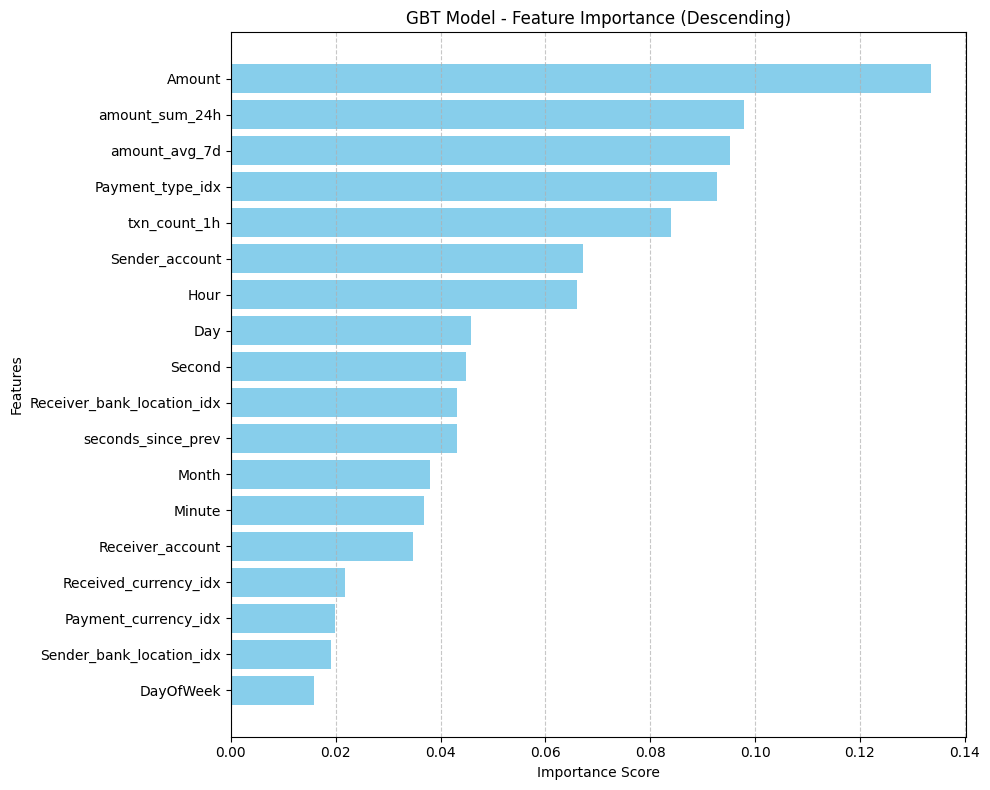

In [144]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Lấy dữ liệu importance và tên cột
importance = gbt_model.featureImportances
feature_list = input_cols

# 2. Chuyển thành Pandas DataFrame để dễ xử lý và sắp xếp
fi_data = pd.DataFrame(list(zip(feature_list, importance.toArray())), 
                       columns=['Feature', 'Importance'])

# 3. Sắp xếp giảm dần theo Importance
fi_data = fi_data.sort_values(by='Importance', ascending=False)

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 8))
plt.barh(fi_data['Feature'][::-1], fi_data['Importance'][::-1], color='skyblue') # Đảo ngược lại để thanh cao nhất nằm trên cùng
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('GBT Model - Feature Importance (Descending)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Hiển thị
plt.show()